In [49]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langchain.messages import SystemMessage
import operator
from langchain.messages import ToolMessage
from typing import Literal
from langgraph.graph import StateGraph, START, END



In [50]:
model = init_chat_model("openai:gpt-4.1-nano", temperature=0)

In [51]:
@tool
def addition(a:float,b:float)->float:
    """to add the to variable a and b"""
    return a + b

@tool
def subtraction(a:float,b:float)->float:
    """to subtract the variable b from a"""
    return a - b

In [52]:
tools=[addition,subtraction]
model_with_tools=model.bind_tools(tools)
model_tool_names={tool.name: tool for tool in tools}

In [80]:
from langchain.messages import HumanMessage


result=model_with_tools.invoke([ SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )]+ [ HumanMessage(content="What is 5 + 9 & result - 1 ?")])



In [81]:

# print(addition.invoke(result.tool_calls[0].get("args")))
result


AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 102, 'total_tokens': 154, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_065579f22e', 'id': 'chatcmpl-DsULTYyUrSFkCLH7W5maqNvXWGXqA', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ee03f-ab6e-78d0-b944-6e1a4f539640-0', tool_calls=[{'name': 'addition', 'args': {'a': 5, 'b': 9}, 'id': 'call_wZWul9qCzeFhECXc165NqfT1', 'type': 'tool_call'}, {'name': 'subtraction', 'args': {'a': 14, 'b': 1}, 'id': 'call_i2DWXeHw9bz3yFQIqry55XWP', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 102, 'output_tokens': 52, 'total_tokens': 154, 'input_toke

In [53]:
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls:int

In [54]:
def llm_calls(state:dict):
    "LLM decides whether to call the LLM or not!"

    return {
        "messages":[
            model_with_tools.invoke(
                [ SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )] + state["messages"]
            )
        ], "llm_calls": state.get("llm_calls", 0) + 1
    }

In [55]:
def tool_node(state:dict):
    """Performs the tool calls"""

    result=[]
    for tool_calls in state["messages"][-1].tool_calls:
        tool=model_tool_names[tool_calls["name"]]
        observation=tool.invoke(tool_calls["args"])
        result.append(ToolMessage(content=observation,tool_call_id=tool_calls["id"]))
    return {"messages":result}

In [56]:
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages=state["messages"]
    last_messages=messages[-1]

    if last_messages.tool_calls:
        return "tool_node"
    return END


In [57]:
agent_builder=StateGraph(MessagesState)

#Add Nodes
agent_builder.add_node("llm_calls", llm_calls)
agent_builder.add_node("tool_node", tool_node)

agent_builder.add_edge(START,"llm_calls")
agent_builder.add_conditional_edges("llm_calls",should_continue,["tool_node", END])
agent_builder.add_edge("tool_node","llm_calls")

agent=agent_builder.compile()


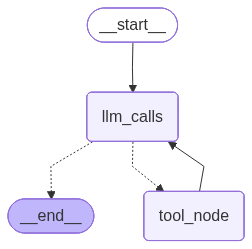

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  addition (call_YqGDk80E1L4y9NCMD9Eg7Ort)
 Call ID: call_YqGDk80E1L4y9NCMD9Eg7Ort
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7.0
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [58]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()